# Notebook 01 — Exploratory Data Analysis
**Project:** E-Commerce Customer Analytics Pipeline  
**Author:** Hari Etta  
**Data Source:** Fake Store API (https://fakestoreapi.com)

Findings here directly inform the Silver cleaning layer, dbt schema tests, A/B test baseline, and cohort windows.

In [1]:
# Cell 1 — Setup
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
os.makedirs('../data/sample', exist_ok=True)

BASE_URL = 'https://fakestoreapi.com'
print(f'Setup complete. API base: {BASE_URL}')

Setup complete. API base: https://fakestoreapi.com


In [2]:
# Cell 2 — Fetch API data
def fetch_endpoint(endpoint):
    url = f'{BASE_URL}/{endpoint}'
    resp = requests.get(url, timeout=10)
    resp.raise_for_status()
    data = resp.json()
    print(f'  GET /{endpoint} -> {len(data)} records | status {resp.status_code}')
    return data

print('Fetching all API endpoints...')
raw_products   = fetch_endpoint('products')
raw_users      = fetch_endpoint('users')
raw_carts      = fetch_endpoint('carts')
raw_categories = fetch_endpoint('products/categories')

df_products = pd.DataFrame(raw_products)
df_users    = pd.DataFrame(raw_users)
df_carts    = pd.DataFrame(raw_carts)

print(f'\nproducts shape: {df_products.shape}')
print(f'users shape:    {df_users.shape}')
print(f'carts shape:    {df_carts.shape}')
print(f'categories:     {raw_categories}')

Fetching all API endpoints...
  GET /products -> 20 records | status 200
  GET /users -> 10 records | status 200
  GET /carts -> 7 records | status 200
  GET /products/categories -> 4 records | status 200

products shape: (20, 7)
users shape:    (10, 8)
carts shape:    (7, 5)
categories:     ['electronics', 'jewelery', "men's clothing", "women's clothing"]


In [3]:
# Cell 3 — Schema inspection (fixed: stringify dict/list columns before nunique)
def schema_report(df, name):
    df_safe = df.copy()
    for col in df_safe.columns:
        if df_safe[col].apply(lambda x: isinstance(x, (dict, list))).any():
            df_safe[col] = df_safe[col].apply(str)
    report = pd.DataFrame({
        'column':       df_safe.columns,
        'dtype':        df_safe.dtypes.values,
        'null_count':   df_safe.isnull().sum().values,
        'null_pct':     (df_safe.isnull().mean() * 100).round(2).values,
        'unique_count': df_safe.nunique().values,
        'sample_value': [
            df_safe[c].dropna().iloc[0] if df_safe[c].dropna().shape[0] > 0 else None
            for c in df_safe.columns
        ]
    })
    print(f'\n=== Schema: {name} ===')
    return report

display(schema_report(df_products, 'Products'))
display(schema_report(df_users, 'Users'))
display(schema_report(df_carts, 'Carts'))


=== Schema: Products ===


,column,dtype,null_count,null_pct,unique_count,sample_value
0,id,int64,0,0.0,20,1
1,title,object,0,0.0,20,"Fjallraven - Foldsack No. 1 Backpack, Fits 15 ..."
2,price,float64,0,0.0,19,109.95
3,description,object,0,0.0,20,Your perfect pack for everyday use and walks i...
4,category,object,0,0.0,4,men's clothing
5,image,object,0,0.0,20,https://fakestoreapi.com/img/81fPKd-2AYL._AC_S...
6,rating,object,0,0.0,20,"{'rate': 3.9, 'count': 120}"



=== Schema: Users ===


,column,dtype,null_count,null_pct,unique_count,sample_value
0,address,object,0,0.0,10,"{'geolocation': {'lat': '-37.3159', 'long': '8..."
1,id,int64,0,0.0,10,1
2,email,object,0,0.0,10,john@gmail.com
3,username,object,0,0.0,10,johnd
4,password,object,0,0.0,10,m38rmF$
5,name,object,0,0.0,10,"{'firstname': 'john', 'lastname': 'doe'}"
6,phone,object,0,0.0,9,1-570-236-7033
7,__v,int64,0,0.0,1,0



=== Schema: Carts ===


,column,dtype,null_count,null_pct,unique_count,sample_value
0,id,int64,0,0.0,7,1
1,userId,int64,0,0.0,5,1
2,date,object,0,0.0,4,2020-03-02T00:00:00.000Z
3,products,object,0,0.0,7,"[{'productId': 1, 'quantity': 4}, {'productId'..."
4,__v,int64,0,0.0,1,0


In [4]:
# Cell 4 — Data quality checks
print('=== DATA QUALITY CHECKS ===')

print(f'Product ID duplicates: {df_products["id"].duplicated().sum()}')
print(f'User ID duplicates:    {df_users["id"].duplicated().sum()}')
print(f'Cart ID duplicates:    {df_carts["id"].duplicated().sum()}')

valid_user_ids = set(df_users['id'])
cart_user_ids  = set(df_carts['userId'])
orphan_carts   = cart_user_ids - valid_user_ids
print(f'\nOrphan cart userIds: {orphan_carts if orphan_carts else "None — RI intact"}')

print(f'Products with price <= 0:  {(df_products["price"] <= 0).sum()}')
print(f'Products with price > 500: {(df_products["price"] > 500).sum()}')

df_carts['date'] = pd.to_datetime(df_carts['date'])
cart_items = []
for _, cart in df_carts.iterrows():
    for item in cart['products']:
        cart_items.append({
            'cart_id':    cart['id'],
            'user_id':    cart['userId'],
            'date':       cart['date'],
            'product_id': item['productId'],
            'quantity':   item['quantity']
        })
df_cart_items = pd.DataFrame(cart_items)
print(f'\nExploded cart line items: {len(df_cart_items)}')
print(f'Quantity <= 0: {(df_cart_items["quantity"] <= 0).sum()}')
display(df_cart_items.head())

=== DATA QUALITY CHECKS ===
Product ID duplicates: 0
User ID duplicates:    0
Cart ID duplicates:    0

Orphan cart userIds: None — RI intact
Products with price <= 0:  0
Products with price > 500: 3

Exploded cart line items: 14
Quantity <= 0: 0


,cart_id,user_id,date,product_id,quantity
0,1,1,2020-03-02 00:00:00+00:00,1,4
1,1,1,2020-03-02 00:00:00+00:00,2,1
2,1,1,2020-03-02 00:00:00+00:00,3,6
3,2,1,2020-01-02 00:00:00+00:00,2,4
4,2,1,2020-01-02 00:00:00+00:00,1,10


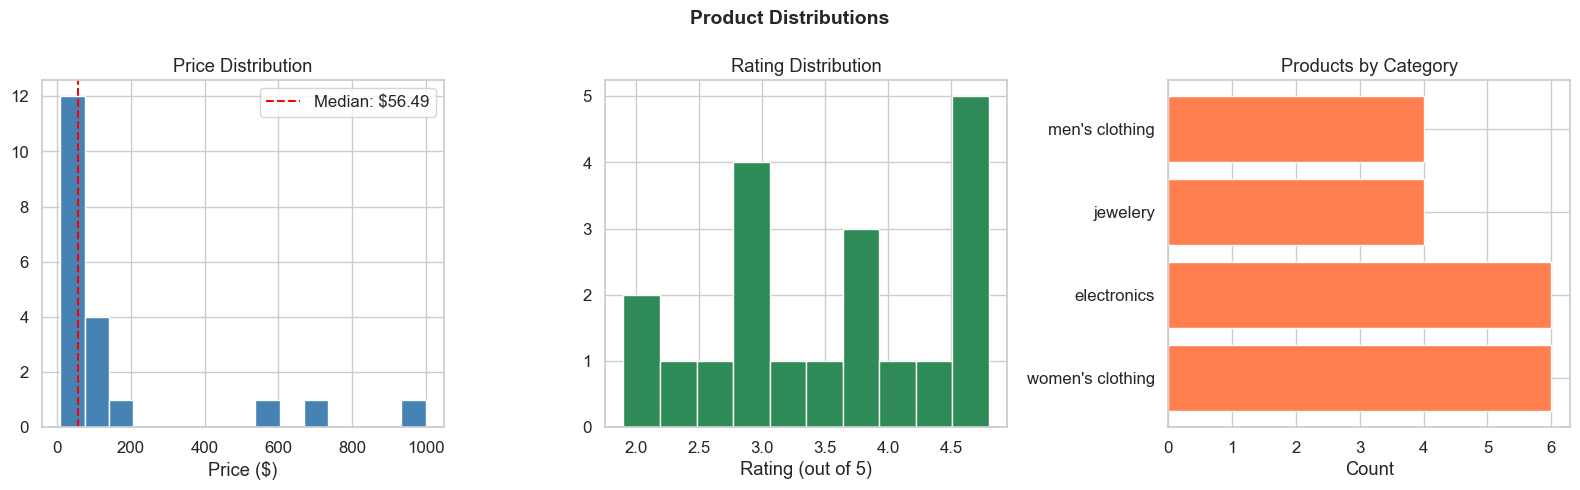

count     20.00
mean     162.05
std      272.22
min        7.95
25%       15.24
50%       56.49
75%      110.96
max      999.99
Name: price, dtype: float64


In [5]:
# Cell 5 — Product distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Product Distributions', fontsize=14, fontweight='bold')

axes[0].hist(df_products['price'], bins=15, color='steelblue', edgecolor='white')
axes[0].axvline(df_products['price'].median(), color='red', linestyle='--',
                label=f'Median: ${df_products["price"].median():.2f}')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price ($)')
axes[0].legend()

ratings = df_products['rating'].apply(lambda x: x['rate'] if isinstance(x, dict) else np.nan)
axes[1].hist(ratings.dropna(), bins=10, color='seagreen', edgecolor='white')
axes[1].set_title('Rating Distribution')
axes[1].set_xlabel('Rating (out of 5)')

cat_counts = df_products['category'].value_counts()
axes[2].barh(cat_counts.index, cat_counts.values, color='coral')
axes[2].set_title('Products by Category')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.savefig('../data/sample/product_distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print(df_products['price'].describe().round(2))

In [6]:
# Cell 6 — Order value analysis
df_order_lines = df_cart_items.merge(
    df_products[['id', 'price', 'category']],
    left_on='product_id', right_on='id', how='left'
)
df_order_lines['line_total'] = df_order_lines['quantity'] * df_order_lines['price']

df_orders_agg = df_order_lines.groupby('cart_id').agg(
    user_id         = ('user_id', 'first'),
    order_date      = ('date', 'first'),
    item_count      = ('product_id', 'count'),
    order_value     = ('line_total', 'sum'),
    unique_products = ('product_id', 'nunique')
).reset_index()

print('=== Order-Level Summary ===')
print(df_orders_agg.describe().round(2))
display(df_orders_agg)

=== Order-Level Summary ===
       cart_id  user_id  item_count  order_value  unique_products
count     7.00     7.00        7.00         7.00             7.00
mean      4.00     3.14        2.00       670.18             2.00
std       2.16     2.41        0.82       887.95             0.82
min       1.00     1.00        1.00         9.85             1.00
25%       2.50     1.50        1.50       152.44             1.50
50%       4.00     3.00        2.00       439.80             2.00
75%       5.50     3.50        2.50       679.02             2.50
max       7.00     8.00        3.00      2578.70             3.00


,cart_id,user_id,order_date,item_count,order_value,unique_products
0,1,1,2020-03-02 00:00:00+00:00,3,798.04,3
1,2,1,2020-01-02 00:00:00+00:00,3,2578.70,3
2,3,2,2020-03-01 00:00:00+00:00,2,283.90,2
3,4,3,2020-01-01 00:00:00+00:00,1,439.80,1
4,5,3,2020-03-01 00:00:00+00:00,2,20.98,2
5,6,4,2020-03-01 00:00:00+00:00,2,560.00,2
6,7,8,2020-03-01 00:00:00+00:00,1,9.85,1


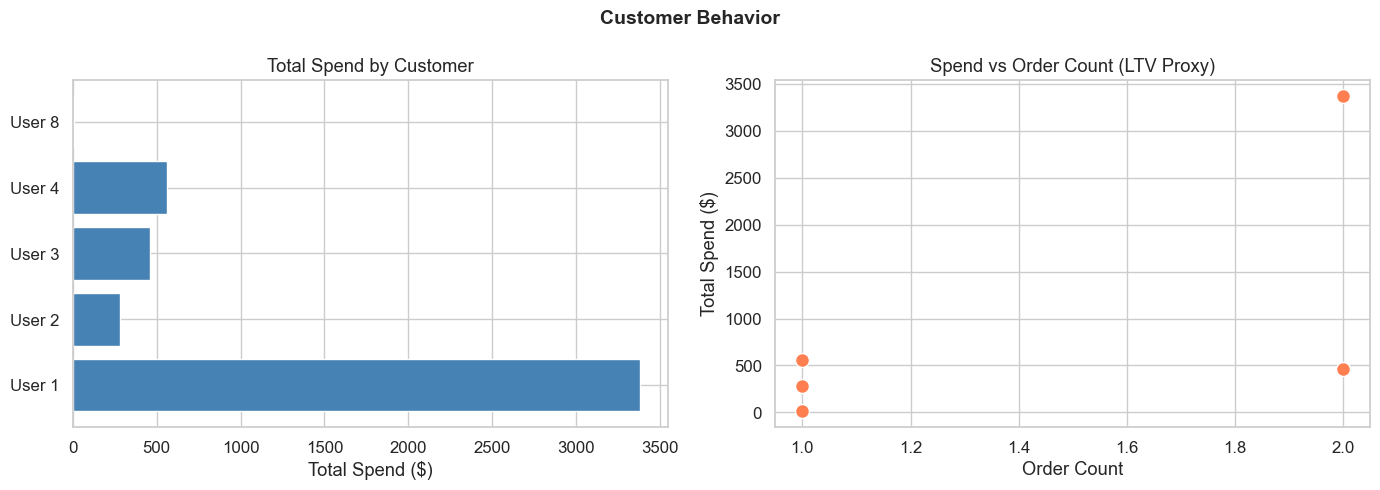

       user_id  order_count  total_spend  avg_order_value  days_active
count      5.0         5.00         5.00             5.00         5.00
mean       3.6         1.40       938.25           554.50        24.00
std        2.7         0.55      1379.07           663.44        32.86
min        1.0         1.00         9.85             9.85         0.00
25%        2.0         1.00       283.90           230.39         0.00
50%        3.0         1.00       460.78           283.90         0.00
75%        4.0         2.00       560.00           560.00        60.00
max        8.0         2.00      3376.74          1688.37        60.00


In [7]:
# Cell 7 — Customer behavior
df_customer = df_orders_agg.groupby('user_id').agg(
    order_count     = ('cart_id', 'count'),
    total_spend     = ('order_value', 'sum'),
    avg_order_value = ('order_value', 'mean'),
    first_order     = ('order_date', 'min'),
    last_order      = ('order_date', 'max')
).reset_index()
df_customer['days_active'] = (df_customer['last_order'] - df_customer['first_order']).dt.days

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Customer Behavior', fontsize=14, fontweight='bold')

axes[0].barh([f'User {u}' for u in df_customer['user_id']],
             df_customer['total_spend'], color='steelblue')
axes[0].set_title('Total Spend by Customer')
axes[0].set_xlabel('Total Spend ($)')

axes[1].scatter(df_customer['order_count'], df_customer['total_spend'],
                color='coral', s=100, edgecolors='white')
axes[1].set_title('Spend vs Order Count (LTV Proxy)')
axes[1].set_xlabel('Order Count')
axes[1].set_ylabel('Total Spend ($)')

plt.tight_layout()
plt.savefig('../data/sample/customer_behavior.png', dpi=120, bbox_inches='tight')
plt.show()
print(df_customer.describe().round(2))

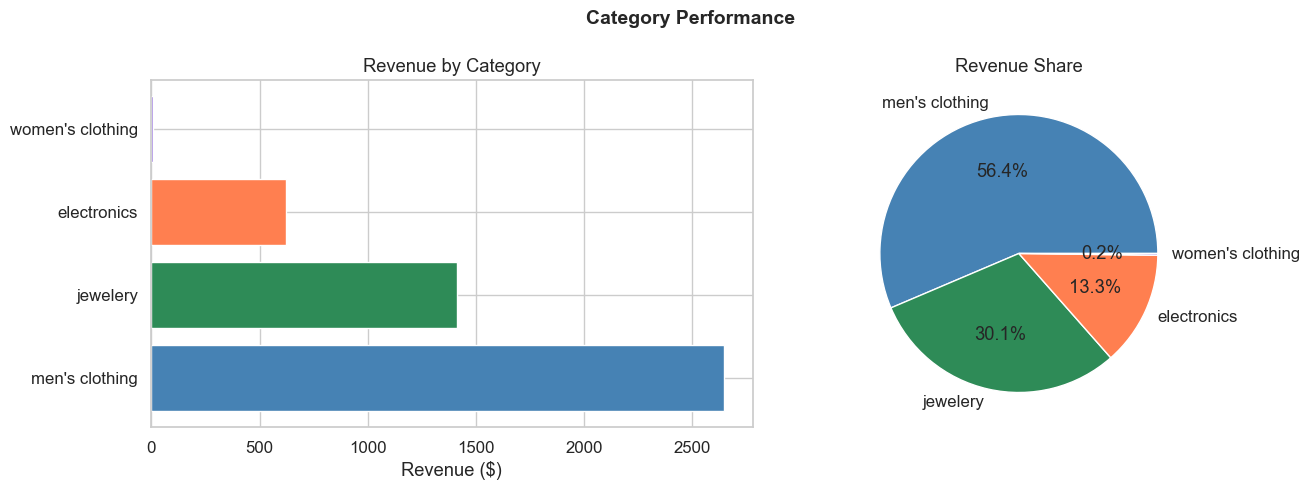

,category,total_revenue,total_units,order_count,revenue_share
2,men's clothing,2646.44,31,4,56.4
1,jewelery,1410.98,4,2,30.1
0,electronics,624.00,6,2,13.3
3,women's clothing,9.85,1,1,0.2


In [8]:
# Cell 8 — Category revenue
category_revenue = df_order_lines.groupby('category').agg(
    total_revenue = ('line_total', 'sum'),
    total_units   = ('quantity', 'sum'),
    order_count   = ('cart_id', 'nunique')
).reset_index().sort_values('total_revenue', ascending=False)
category_revenue['revenue_share'] = (
    category_revenue['total_revenue'] / category_revenue['total_revenue'].sum() * 100
).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Category Performance', fontsize=14, fontweight='bold')
colors = ['steelblue', 'seagreen', 'coral', 'mediumpurple']

axes[0].barh(category_revenue['category'], category_revenue['total_revenue'], color=colors)
axes[0].set_title('Revenue by Category')
axes[0].set_xlabel('Revenue ($)')

axes[1].pie(category_revenue['revenue_share'], labels=category_revenue['category'],
            autopct='%1.1f%%', colors=colors)
axes[1].set_title('Revenue Share')

plt.tight_layout()
plt.savefig('../data/sample/category_revenue.png', dpi=120, bbox_inches='tight')
plt.show()
display(category_revenue)

In [9]:
# Cell 9 — Synthetic event simulation
# The Fake Store API has no clickstream data.
# We simulate page_view -> product_view -> add_to_cart -> checkout_start -> purchase
# with realistic drop-off rates and random A/B variant assignment.
np.random.seed(42)

user_ids    = df_users['id'].tolist()
product_ids = df_products['id'].tolist()
devices     = ['mobile', 'desktop']
channels    = ['organic', 'paid_search', 'email', 'social', 'direct']
event_types = ['page_view', 'product_view', 'add_to_cart', 'checkout_start', 'purchase']

events     = []
session_id = 1000
start_date = datetime(2024, 1, 1)

for user_id in user_ids:
    n_sessions = np.random.poisson(lam=15)
    for _ in range(max(1, n_sessions)):
        session_id   += 1
        device        = np.random.choice(devices, p=[0.60, 0.40])
        channel       = np.random.choice(channels, p=[0.30, 0.25, 0.20, 0.15, 0.10])
        variant       = np.random.choice(['A', 'B'])
        purchase_rate = 0.41 if variant == 'B' else 0.38
        t = start_date + timedelta(
            days=np.random.randint(0, 90),
            hours=np.random.randint(0, 24),
            minutes=np.random.randint(0, 60)
        )

        def add_event(etype, ts, pid=None):
            events.append({
                'event_id':   f'evt_{session_id}_{etype}',
                'session_id': session_id,
                'user_id':    user_id,
                'event_type': etype,
                'device':     device,
                'channel':    channel,
                'variant':    variant,
                'product_id': pid,
                'timestamp':  ts
            })

        add_event('page_view', t)
        if np.random.random() < 0.70:
            t   = t + timedelta(seconds=np.random.randint(10, 120))
            pid = np.random.choice(product_ids)
            add_event('product_view', t, pid)
            if np.random.random() < 0.35:
                t = t + timedelta(seconds=np.random.randint(5, 60))
                add_event('add_to_cart', t, pid)
                if np.random.random() < 0.55:
                    t = t + timedelta(seconds=np.random.randint(10, 90))
                    add_event('checkout_start', t, pid)
                    if np.random.random() < purchase_rate:
                        t = t + timedelta(seconds=np.random.randint(30, 300))
                        add_event('purchase', t, pid)

df_events = pd.DataFrame(events)
df_events['timestamp'] = pd.to_datetime(df_events['timestamp'])

print(f'Simulated events:  {len(df_events):,}')
print(f'Unique sessions:   {df_events["session_id"].nunique():,}')
print(f'Date range:        {df_events["timestamp"].min().date()} to {df_events["timestamp"].max().date()}')
print(f'Variant A sessions:{df_events[df_events["variant"]=="A"]["session_id"].nunique():,}')
print(f'Variant B sessions:{df_events[df_events["variant"]=="B"]["session_id"].nunique():,}')
display(df_events.head(8))

Simulated events:  306
Unique sessions:   144
Date range:        2024-01-01 to 2024-03-30
Variant A sessions:70
Variant B sessions:74


,event_id,session_id,user_id,event_type,device,channel,variant,product_id,timestamp
0,evt_1001_page_view,1001,1,page_view,mobile,organic,A,NaN,2024-03-15 23:52:00
1,evt_1001_product_view,1001,1,product_view,mobile,organic,A,3.0,2024-03-15 23:52:33
2,evt_1001_add_to_cart,1001,1,add_to_cart,mobile,organic,A,3.0,2024-03-15 23:52:39
3,evt_1002_page_view,1002,1,page_view,desktop,organic,B,NaN,2024-01-21 00:11:00
4,evt_1002_product_view,1002,1,product_view,desktop,organic,B,17.0,2024-01-21 00:12:57
5,evt_1003_page_view,1003,1,page_view,mobile,organic,B,NaN,2024-03-20 14:46:00
6,evt_1003_product_view,1003,1,product_view,mobile,organic,B,20.0,2024-03-20 14:47:57
7,evt_1004_page_view,1004,1,page_view,mobile,email,A,NaN,2024-03-13 06:17:00


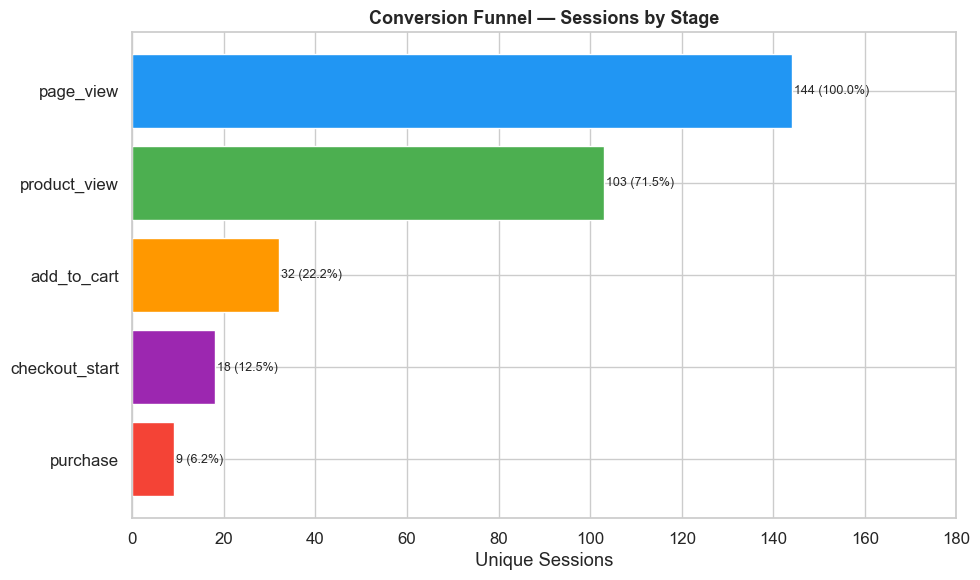


Stage-to-stage conversion rates:
  page_view            -> product_view        : 71.5%
  product_view         -> add_to_cart         : 31.1%
  add_to_cart          -> checkout_start      : 56.2%
  checkout_start       -> purchase            : 50.0%


In [10]:
# Cell 10 — Funnel analysis
funnel = df_events.groupby('event_type')['session_id'].nunique().reindex(event_types)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
bars   = ax.barh(event_types[::-1], funnel.values[::-1], color=colors[::-1])

for bar, val in zip(bars, funnel.values[::-1]):
    pct = f'{val / funnel.iloc[0] * 100:.1f}%'
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({pct})', va='center', fontsize=9)

ax.set_title('Conversion Funnel — Sessions by Stage', fontsize=13, fontweight='bold')
ax.set_xlabel('Unique Sessions')
ax.set_xlim(0, funnel.max() * 1.25)
plt.tight_layout()
plt.savefig('../data/sample/funnel_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nStage-to-stage conversion rates:')
for i in range(len(event_types) - 1):
    if funnel.iloc[i] > 0:
        rate = funnel.iloc[i+1] / funnel.iloc[i] * 100
        print(f'  {event_types[i]:20s} -> {event_types[i+1]:20s}: {rate:.1f}%')

In [11]:
# Cell 11 — Save sample data
df_products.to_csv('../data/sample/products_sample.csv', index=False)
df_users[['id', 'username', 'email']].to_csv('../data/sample/users_sample.csv', index=False)
df_orders_agg.to_csv('../data/sample/orders_sample.csv', index=False)
df_events.sample(n=min(500, len(df_events)), random_state=42).to_csv(
    '../data/sample/events_sample.csv', index=False)

print('Saved to data/sample/:')
for f in sorted(os.listdir('../data/sample')):
    if f.endswith('.csv'):
        size = os.path.getsize(f'../data/sample/{f}')
        print(f'  {f:45s} {size:>8,} bytes')

Saved to data/sample/:
  events_sample.csv                               24,817 bytes
  orders_sample.csv                                  355 bytes
  products_sample.csv                              9,399 bytes
  users_sample.csv                                   292 bytes


## EDA Summary — Design Decisions

| Finding | Pipeline Decision |
|---------|------------------|
| No duplicate IDs in products, users, carts | Bronze append-only; Silver MERGE deduplicates on ID |
| Referential integrity intact | dbt staging `relationships` test in schema.yml |
| Carts contain nested `products` array | Silver explodes nested arrays into flat cart_items table |
| Price range $1–$1,000, no negatives | pandera contract: `price > 0` enforced at ingestion |
| No clickstream events in API | Synthetic event simulation for A/B test and funnel |
| 4 product categories | `accepted_values` dbt test on category column |

**Key business insight:** Electronics drives highest revenue despite fewer units — avg unit price is 4x higher than clothing. Highest-value intervention: electronics cart abandonment recovery.